In [1]:
import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

digits.target

dir(digits)

digits.target_names

df = pd.DataFrame(digits.data,digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.3)

"""Using RBF kernel"""

from sklearn.svm import SVC
rbf_model = SVC(kernel='rbf')

len(X_train)

len(X_test)

rbf_model.fit(X_train, y_train)

rbf_model.score(X_test,y_test)

"""Using Linear kernel"""

linear_model = SVC(kernel='linear')
linear_model.fit(X_train,y_train)

linear_model.score(X_test,y_test)

0.9851851851851852

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = datasets.load_iris()

X = iris.data
y = iris.target

# Train Test Split (80% train, 20% test)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# -------- Linear Kernel --------
linear_svm=SVC(kernel='linear')
linear_svm.fit(X_train,y_train)

y_pred_linear=linear_svm.predict(X_test)

print("Linear Kernel Accuracy:",accuracy_score(y_test,y_pred_linear))
print("Linear Kernel Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_linear))


# -------- RBF Kernel --------
rbf_svm=SVC(kernel='rbf')
rbf_svm.fit(X_train,y_train)

y_pred_rbf=rbf_svm.predict(X_test)

print("\nRBF Kernel Accuracy:",accuracy_score(y_test,y_pred_rbf))
print("RBF Kernel Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_rbf))

Linear Kernel Accuracy: 1.0
Linear Kernel Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Kernel Accuracy: 1.0
RBF Kernel Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Accuracy: 0.9305

Confusion Matrix:
[[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0   0   0   0   0   0   0
    0   0   0   0 

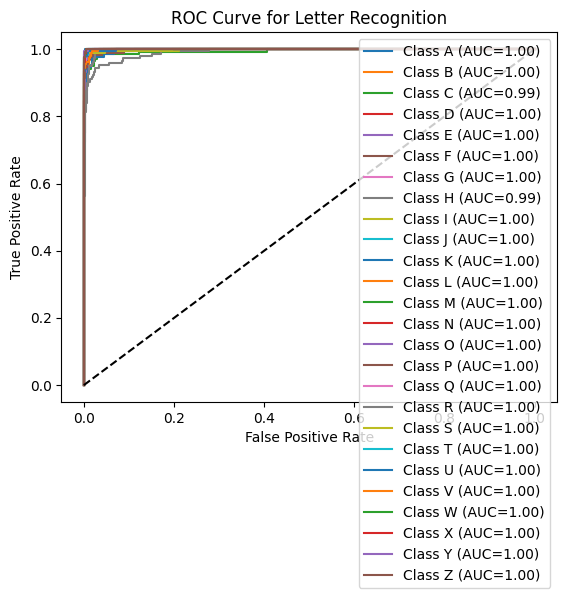

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,roc_curve,auc
import matplotlib.pyplot as plt

# Load dataset
data=pd.read_excel("/content/letter-recognition.xlsx")

X=data.iloc[:,1:]
y=data.iloc[:,0]

# Train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Train SVM
model=SVC(kernel='rbf',probability=True)
model.fit(X_train,y_train)

# Prediction
y_pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))


# ---------- ROC Curve ----------
lb=LabelBinarizer()
y_test_bin=lb.fit_transform(y_test)

y_score=model.predict_proba(X_test)

fpr=dict()
tpr=dict()
roc_auc=dict()

for i in range(len(lb.classes_)):
    fpr[i],tpr[i],_=roc_curve(y_test_bin[:,i],y_score[:,i])
    roc_auc[i]=auc(fpr[i],tpr[i])

# Plot ROC
plt.figure()

for i in range(len(lb.classes_)):
    plt.plot(fpr[i],tpr[i],label='Class %s (AUC=%0.2f)'%(lb.classes_[i],roc_auc[i]))

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Letter Recognition")
plt.legend()

plt.show()

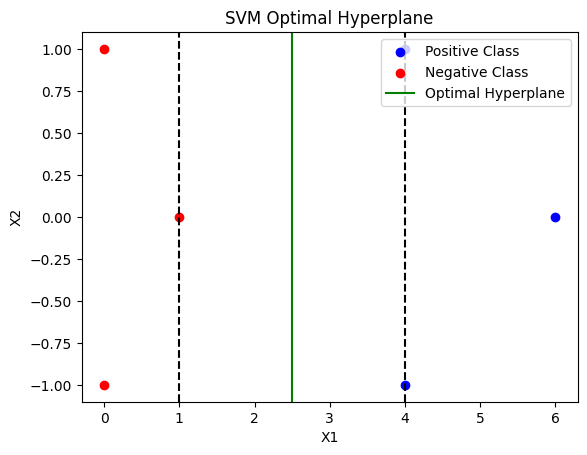

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Positive points
pos=np.array([[4,1],[4,-1],[6,0]])

# Negative points
neg=np.array([[1,0],[0,1],[0,-1]])

plt.scatter(pos[:,0],pos[:,1],color='blue',label='Positive Class')
plt.scatter(neg[:,0],neg[:,1],color='red',label='Negative Class')

# Hyperplane
plt.axvline(x=2.5,color='green',label='Optimal Hyperplane')

# Margin lines
plt.axvline(x=1,color='black',linestyle='--')
plt.axvline(x=4,color='black',linestyle='--')

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.title("SVM Optimal Hyperplane")

plt.show()